# SIMILIS baseline: split, preprocessing, dataloaders

`group-aware split`, image preprocessing / augmentations и `Dataset + DataLoader` с sanity-check

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
import torchvision.transforms as T

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

/opt/miniconda3/envs/similis-baseline/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/miniconda3/envs/similis-baseline/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/miniconda3/envs/similis-baseline/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/miniconda3/envs/similis-baseline/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/similis-baseline/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/similis-baseline/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/similis-baseline/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, 

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'interim' / 'manifest_raw.csv'
SPLITS_DIR = PROJECT_ROOT / 'splits'
REPORTS_DIR = PROJECT_ROOT / 'artifacts' / 'reports'
FIGURES_DIR = PROJECT_ROOT / 'artifacts' / 'figures'
for p in [SPLITS_DIR, REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MANIFEST_PATH)
df = df[df['image_exists'] == True].copy()
df['description'] = df['description'].fillna('')
df['artifact_id'] = df['code'].astype(str)
df['group_key'] = df['artifact_id']
df['image_path'] = df['image_path'].astype(str)
print('Rows:', len(df))
print('Unique groups:', df['group_key'].nunique())

Rows: 1387
Unique groups: 1387


Сначала повторяем нормализацию целевых колонок, чтобы split, preprocessing и `Dataset` работали уже на зафиксированных baseline-целях.

In [3]:
object_type_map = {
    'Тарелка': 'тарелка', 'Тарелка/блюдо': 'тарелка', 'Блюдце': 'блюдце',
    'Миска': 'миска', 'Миска (?)': 'миска', 'Крышка': 'крышка',
    'Изразец': 'изразец', 'Плитка': 'плитка', 'Игрушка': 'игрушка', 'Игрушка ёлочная': 'игрушка',
}
material_map = {
    'Керамика': 'ceramic', 'Красноглиняная керамика': 'ceramic', 'Белоглиняная керамика': 'ceramic',
    'Светлоглиняная керамика': 'ceramic', 'Серолощеная керамика': 'ceramic', 'Глина': 'clay',
    'Фаянс': 'faience', 'Фарфор': 'porcelain', 'Стекло': 'glass', 'Каменная масса': 'stoneware',
    'Камень': 'stone', 'Песчаник': 'stone', 'Сланец': 'stone', 'Гранит': 'stone',
    'Металл': 'metal', 'Белый металл': 'metal', 'Бронза': 'metal',
    'Дерево': 'other', 'Пластмасса': 'other', 'Резина': 'other',
    'Основание - бетон, покрытие - композитный материал': 'other',
}
integrity_map = {'Фрагмент': 'fragment', 'Целый': 'whole'}
part_zone_rules = [
    ('донце', 'base'), ('донца', 'base'), ('венчик', 'rim'), ('края', 'rim'),
    ('профиль', 'profile'), ('стенка', 'wall'), ('стенки', 'wall'),
    ('крышка', 'lid'), ('крышечки', 'lid'), ('крышки', 'lid'),
    ('ручка', 'handle'), ('ручки', 'handle'),
]
def extract_part_zone(text: str) -> str:
    text = (text or '').lower()
    for needle, label in part_zone_rules:
        if needle in text:
            return label
    return 'unknown'

df['object_type'] = df['name'].map(object_type_map).fillna('other')
df['material_group'] = df['material'].map(material_map).fillna('other')
df['integrity'] = df['fragm'].map(integrity_map).fillna('unknown')
df['part_zone'] = df['description'].map(extract_part_zone)

target_cols = ['object_type', 'integrity', 'material_group', 'part_zone']
for col in target_cols:
    print('\n', col)
    print(df[col].value_counts().to_string())


 object_type
object_type
тарелка    484
изразец    361
блюдце     216
крышка     177
миска      117
плитка      26
игрушка      6

 integrity
integrity
fragment    1258
whole        129

 material_group
material_group
ceramic      630
faience      368
porcelain    307
glass         28
clay          26
other         14
stone          8
stoneware      3
metal          3

 part_zone
part_zone
unknown    598
rim        265
profile    204
base       191
lid        112
wall        12
handle       5


## Task 8. Group-aware split

In [4]:
print('Files in dataset dir:', len(list((PROJECT_ROOT / 'data' / 'raw' / 'cu_data' / 'cu_data' / 'dataset').glob('*.jpg'))))
print('Rows in manifest with valid image:', len(df))
print('Unique group_key:', df['group_key'].nunique())
print('Max images per group in matched subset:', int(df.groupby('group_key').size().max()))

Files in dataset dir: 1388
Rows in manifest with valid image: 1387
Unique group_key: 1387
Max images per group in matched subset: 1


В этом открытом baseline-подмножестве после надёжного матчинга `csv ↔ image` на каждый `group_key=code` приходится один канонический файл `*_orig.jpg`.

То есть здесь группировка всё равно нужна и фиксируется честно, но реальные matched-группы в основном размера `1`. Это лучше, чем искусственно привязывать неподтверждённые дополнительные кадры и рисковать ошибочным соответствием.

In [5]:
sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
y_outer = df['object_type']
groups = df['group_key']
train_val_idx, test_idx = next(sgkf_outer.split(df, y_outer, groups))

train_val_df = df.iloc[train_val_idx].copy().reset_index(drop=True)
test_open_df = df.iloc[test_idx].copy().reset_index(drop=True)

sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
y_inner = train_val_df['object_type']
groups_inner = train_val_df['group_key']
train_idx, val_idx = next(sgkf_inner.split(train_val_df, y_inner, groups_inner))

train_inner_df = train_val_df.iloc[train_idx].copy().reset_index(drop=True)
val_inner_df = train_val_df.iloc[val_idx].copy().reset_index(drop=True)

train_inner_df['split'] = 'train_inner'
val_inner_df['split'] = 'val_inner'
test_open_df['split'] = 'test_open'
split_df = pd.concat([train_inner_df, val_inner_df, test_open_df], ignore_index=True)

split_df.to_csv(SPLITS_DIR / 'open_grouped_split.csv', index=False)
print('Saved split to', SPLITS_DIR / 'open_grouped_split.csv')
split_df['split'].value_counts()

Saved split to /Users/artemvardanan/Downloads/DL_project1/splits/open_grouped_split.csv


split
train_inner    887
test_open      278
val_inner      222
Name: count, dtype: int64

In [6]:
print('train_inner:', len(train_inner_df))
print('val_inner:', len(val_inner_df))
print('test_open:', len(test_open_df))

train_inner: 887
val_inner: 222
test_open: 278


In [7]:
train_groups = set(train_inner_df['group_key'])
val_groups = set(val_inner_df['group_key'])
test_groups = set(test_open_df['group_key'])

print('train ∩ val:', len(train_groups & val_groups))
print('train ∩ test:', len(train_groups & test_groups))
print('val ∩ test:', len(val_groups & test_groups))

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0


In [8]:
def class_share(frame, col, top_n=10):
    s = frame[col].value_counts(normalize=True).head(top_n)
    return s.rename(frame['split'].iloc[0])

for col in ['object_type', 'material_group', 'integrity']:
    print(f'\nDistribution for {col}')
    dist = pd.concat([
        class_share(train_inner_df.assign(split='train_inner'), col),
        class_share(val_inner_df.assign(split='val_inner'), col),
        class_share(test_open_df.assign(split='test_open'), col),
    ], axis=1).fillna(0)
    display(dist.head(15))


Distribution for object_type


,train_inner,val_inner,test_open
object_type,,,
тарелка,0.348365,0.351351,0.348921
изразец,0.260428,0.256757,0.262590
блюдце,0.155581,0.157658,0.154676
крышка,0.128523,0.126126,0.125899
миска,0.084555,0.085586,0.082734
плитка,0.018038,0.018018,0.021583
игрушка,0.004510,0.004505,0.003597



Distribution for material_group


,train_inner,val_inner,test_open
material_group,,,
ceramic,0.462232,0.436937,0.442446
faience,0.260428,0.252252,0.291367
porcelain,0.210823,0.270270,0.215827
glass,0.021421,0.013514,0.021583
clay,0.020293,0.018018,0.014388
other,0.012401,0.000000,0.010791
stone,0.006764,0.009009,0.000000
stoneware,0.003382,0.000000,0.000000
metal,0.002255,0.000000,0.003597



Distribution for integrity


,train_inner,val_inner,test_open
integrity,,,
fragment,0.905299,0.900901,0.917266
whole,0.094701,0.099099,0.082734


In [9]:
def make_split(seed):
    sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    train_val_idx, test_idx = next(sgkf_outer.split(df, df['object_type'], df['group_key']))
    train_val_df = df.iloc[train_val_idx].copy().reset_index(drop=True)
    sgkf_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    train_idx, val_idx = next(sgkf_inner.split(train_val_df, train_val_df['object_type'], train_val_df['group_key']))
    return (
        tuple(sorted(train_val_df.iloc[train_idx]['group_key'].tolist())),
        tuple(sorted(train_val_df.iloc[val_idx]['group_key'].tolist())),
        tuple(sorted(df.iloc[test_idx]['group_key'].tolist())),
    )

split_a = make_split(SEED)
split_b = make_split(SEED)
print('Deterministic split with same seed:', split_a == split_b)

Deterministic split with same seed: True


In [10]:
group_examples = split_df[['group_key', 'image_file', 'split', 'object_type', 'material_group']].sample(3, random_state=SEED)
display(group_examples.sort_values('group_key'))

,group_key,image_file,split,object_type,material_group
208,КБ-2014-Р2-0323,КБ-2014-Р2-0323_orig.jpg,train_inner,миска,ceramic
947,КБ-2014-Р3-0171,КБ-2014-Р3-0171_orig.jpg,val_inner,тарелка,porcelain
649,Нейш3А-2018-2548,Нейш3А-2018-2548_orig.jpg,train_inner,крышка,porcelain


## Task 9. Preprocessing and augmentations

In [11]:
IMAGE_SIZE = 384
print('Input size:', IMAGE_SIZE)

Input size: 384


In [12]:
class ResizeLongestSidePad:
    def __init__(self, size, fill=(255, 255, 255)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        img = img.convert('RGB')
        w, h = img.size
        scale = self.size / max(w, h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = img.resize((new_w, new_h), Image.Resampling.BILINEAR)
        canvas = Image.new('RGB', (self.size, self.size), self.fill)
        left = (self.size - new_w) // 2
        top = (self.size - new_h) // 2
        canvas.paste(resized, (left, top))
        return canvas

train_transform = T.Compose([
    ResizeLongestSidePad(IMAGE_SIZE),
    T.RandomRotation(degrees=7, fill=255),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    ResizeLongestSidePad(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

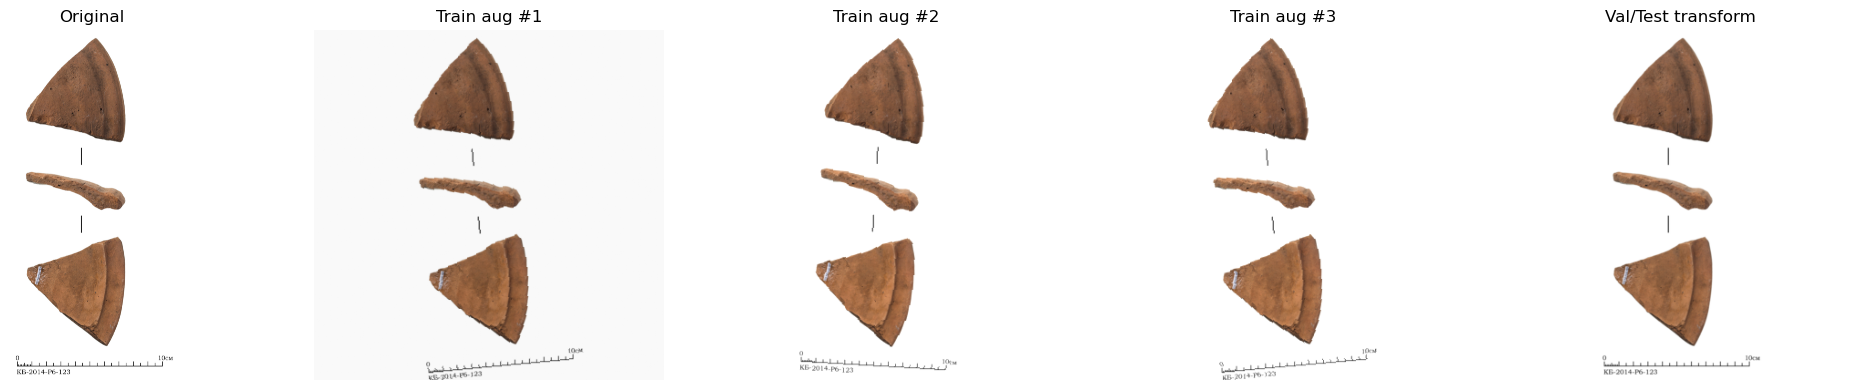

In [13]:
def denorm(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = tensor.cpu() * std + mean
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()

sample_row = train_inner_df.sample(1, random_state=SEED).iloc[0]
img = Image.open(sample_row['image_path']).convert('RGB')

aug1 = train_transform(img)
aug2 = train_transform(img)
aug3 = train_transform(img)
val_img = val_transform(img)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(denorm(aug1))
axes[1].set_title('Train aug #1')
axes[2].imshow(denorm(aug2))
axes[2].set_title('Train aug #2')
axes[3].imshow(denorm(aug3))
axes[3].set_title('Train aug #3')
axes[4].imshow(denorm(val_img))
axes[4].set_title('Val/Test transform')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

Выбранная схема preprocessing:

- `ResizeLongestSide + Pad` до `384x384`;
- нормализация ImageNet-статистиками;
- train-аугментации: маленький `RandomRotation`, умеренный `ColorJitter(brightness/contrast)`;
- на `val/test` только детерминированное преобразование без случайных искажений.

Чего мы специально не делаем:

- агрессивный `CenterCrop` / `RandomResizedCrop`;
- сильные сдвиги hue/saturation;
- cross-object mosaic / CutMix;
- полную инверсию фона или всего изображения.

Это важно, потому что материал, полива, клейма и мелкие детали чувствительны к агрессивным искажениям.

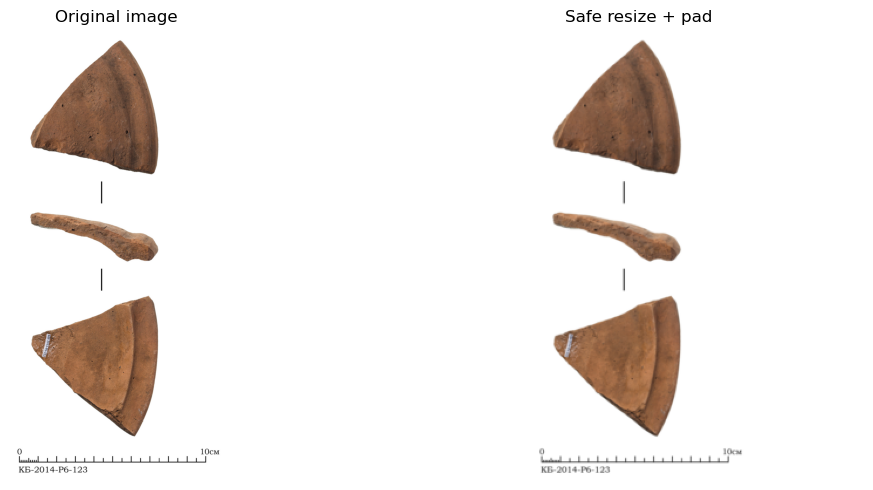

In [14]:
safe_crop_example = image_path = Path(sample_row['image_path'])
with Image.open(image_path).convert('RGB') as base_img:
    resized_padded = ResizeLongestSidePad(IMAGE_SIZE)(base_img)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(Image.open(image_path).convert('RGB'))
axes[0].set_title('Original image')
axes[1].imshow(resized_padded)
axes[1].set_title('Safe resize + pad')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## Task 10. Dataset + DataLoader and final sanity-check

In [15]:
label_vocab = {
    'object_type': sorted(df['object_type'].unique().tolist()),
    'integrity': sorted(df['integrity'].unique().tolist()),
    'material_group': sorted(df['material_group'].unique().tolist()),
    'part_zone': sorted(df['part_zone'].unique().tolist()),
}
label_to_idx = {k: {label: i for i, label in enumerate(v)} for k, v in label_vocab.items()}
idx_to_label = {k: {i: label for label, i in v.items()} for k, v in label_to_idx.items()}
label_vocab

{'object_type': ['блюдце',
  'игрушка',
  'изразец',
  'крышка',
  'миска',
  'плитка',
  'тарелка'],
 'integrity': ['fragment', 'whole'],
 'material_group': ['ceramic',
  'clay',
  'faience',
  'glass',
  'metal',
  'other',
  'porcelain',
  'stone',
  'stoneware'],
 'part_zone': ['base', 'handle', 'lid', 'profile', 'rim', 'unknown', 'wall']}

In [16]:
class SimilisBaselineDataset(Dataset):
    def __init__(self, frame, transform, label_to_idx):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform
        self.label_to_idx = label_to_idx
        self.target_cols = ['object_type', 'integrity', 'material_group', 'part_zone']

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        image = self.transform(img)

        targets = {}
        target_mask = {}
        for col in self.target_cols:
            value = row[col]
            targets[col] = self.label_to_idx[col][value]
            target_mask[col] = 0 if value in ['unknown'] else 1

        metadata = {
            'image_file': row['image_file'],
            'group_key': row['group_key'],
            'image_path': row['image_path'],
        }
        return {
            'image': image,
            'targets': targets,
            'target_mask': target_mask,
            'metadata': metadata,
        }

def collate_fn(batch):
    images = torch.stack([b['image'] for b in batch], dim=0)
    target_cols = batch[0]['targets'].keys()
    targets = {col: torch.tensor([b['targets'][col] for b in batch], dtype=torch.long) for col in target_cols}
    target_mask = {col: torch.tensor([b['target_mask'][col] for b in batch], dtype=torch.float32) for col in target_cols}
    metadata = {k: [b['metadata'][k] for b in batch] for k in batch[0]['metadata'].keys()}
    return {'image': images, 'targets': targets, 'target_mask': target_mask, 'metadata': metadata}

In [17]:
train_ds = SimilisBaselineDataset(train_inner_df, train_transform, label_to_idx)
val_ds = SimilisBaselineDataset(val_inner_df, val_transform, label_to_idx)
test_ds = SimilisBaselineDataset(test_open_df, val_transform, label_to_idx)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)

In [18]:
batch = next(iter(train_loader))
print('image shape:', batch['image'].shape)
print('image dtype:', batch['image'].dtype)
for col in batch['targets']:
    print(col, batch['targets'][col].shape, batch['targets'][col].dtype, batch['target_mask'][col].shape, batch['target_mask'][col].dtype)

image shape: torch.Size([8, 3, 384, 384])
image dtype: torch.float32
object_type torch.Size([8]) torch.int64 torch.Size([8]) torch.float32
integrity torch.Size([8]) torch.int64 torch.Size([8]) torch.float32
material_group torch.Size([8]) torch.int64 torch.Size([8]) torch.float32
part_zone torch.Size([8]) torch.int64 torch.Size([8]) torch.float32


In [19]:
i = 0
decoded = {col: idx_to_label[col][int(batch['targets'][col][i])] for col in batch['targets']}
print('image_file:', batch['metadata']['image_file'][i])
print('group_key:', batch['metadata']['group_key'][i])
print('decoded targets:', decoded)
print('target_mask:', {col: float(batch['target_mask'][col][i]) for col in batch['target_mask']})

image_file: КБ-2014-Р2-0780_orig.jpg
group_key: КБ-2014-Р2-0780
decoded targets: {'object_type': 'крышка', 'integrity': 'fragment', 'material_group': 'faience', 'part_zone': 'lid'}
target_mask: {'object_type': 1.0, 'integrity': 1.0, 'material_group': 1.0, 'part_zone': 1.0}


In [20]:
def build_auto_description(fields, conf=None, thresholds=None):
    conf = conf or {}
    thresholds = thresholds or {'object_type': 0.0, 'integrity': 0.0, 'part_zone': 0.6, 'material_group': 0.65}
    material_text = {'ceramic': 'керамический', 'clay': 'глиняный', 'faience': 'фаянсовый', 'porcelain': 'фарфоровый', 'glass': 'стеклянный', 'stoneware': 'из каменной массы', 'stone': 'каменный', 'metal': 'металлический', 'other': None}
    part_text = {'base': 'донце', 'rim': 'венчик/край', 'profile': 'профиль', 'wall': 'стенка', 'lid': 'крышка', 'handle': 'ручка', 'unknown': None}
    integrity_text = {'fragment': 'фрагмент', 'whole': 'целый предмет', 'unknown': 'предмет'}
    tokens = [fields.get('object_type', 'предмет'), integrity_text.get(fields.get('integrity', 'unknown'), 'предмет')]
    if conf.get('part_zone', 1.0) >= thresholds['part_zone'] and part_text.get(fields.get('part_zone', 'unknown')):
        tokens.append(part_text[fields['part_zone']])
    if conf.get('material_group', 1.0) >= thresholds['material_group'] and material_text.get(fields.get('material_group', 'other')):
        tokens.append(material_text[fields['material_group']])
    return ', '.join(tokens)

gt_desc = build_auto_description(decoded, conf={'part_zone': 1.0, 'material_group': 1.0})
print('Ground-truth auto_description:', gt_desc)

Ground-truth auto_description: крышка, фрагмент, крышка, фаянсовый


Train image path: /Users/artemvardanan/Downloads/DL_project1/data/raw/cu_data/cu_data/dataset/М102-2012-1-0494_orig.jpg
Val image path: /Users/artemvardanan/Downloads/DL_project1/data/raw/cu_data/cu_data/dataset/М102-2012-1-0843_orig.jpg
Train target_mask: {'object_type': 1, 'integrity': 1, 'material_group': 1, 'part_zone': 0}
Val target_mask: {'object_type': 1, 'integrity': 1, 'material_group': 1, 'part_zone': 1}


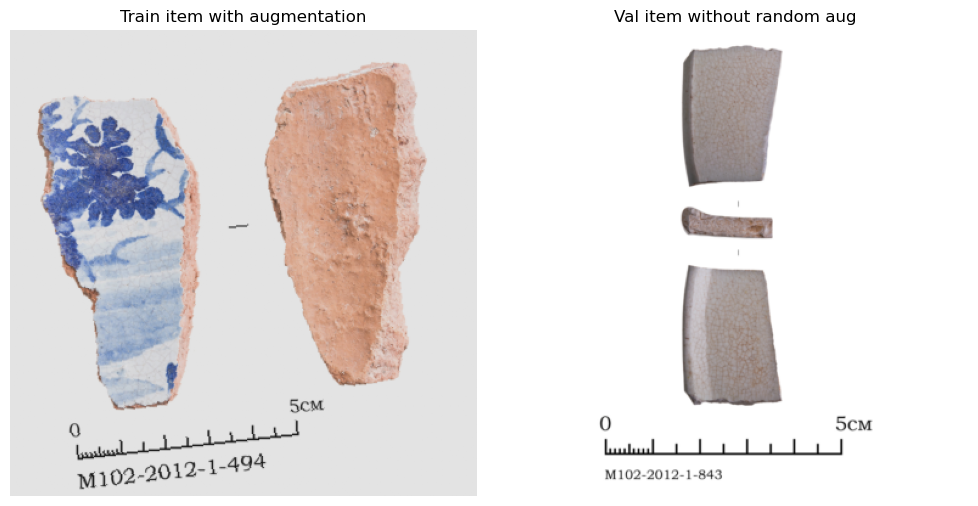

In [21]:
train_item = train_ds[0]
val_item = val_ds[0]
print('Train image path:', train_item['metadata']['image_path'])
print('Val image path:', val_item['metadata']['image_path'])
print('Train target_mask:', train_item['target_mask'])
print('Val target_mask:', val_item['target_mask'])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(denorm(train_item['image']))
axes[0].set_title('Train item with augmentation')
axes[1].imshow(denorm(val_item['image']))
axes[1].set_title('Val item without random aug')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

Sanity-check, который должен быть пройден до модели:

- путь и картинка реально совпадают;
- на `train` есть случайные аугментации, на `val/test` их нет;
- `target_mask` корректно обнуляет только `unknown`-цели;
- из ground-truth полей батча можно собрать `auto_description`.